# Legal AI Document Intelligence & Classification


## Project Overview
**Goal:** classify legal clauses into one of **100 legal document categories** using the LEDGAR dataset from LexGLUE.

This notebook reproduces the project workflow: data analysis, TF-IDF baselines, Random Forest, XGBoost, a PyTorch neural network, BERT, RoBERTa, T5, error analysis, and Random Forest explainability.

### Recorded results
| Model | Accuracy | Macro F1 | Weighted F1 |
|---|---:|---:|---:|
| TF-IDF + Random Forest | 86.15% | 78.74% | 85.37% |
| TF-IDF + Logistic Regression | 83.28% | 77.10% | 83.79% |
| TF-IDF + XGBoost | 81.20% | 72.79% | 80.39% |
| PyTorch Neural Network | 79.03% | 71.25% | 79.52% |
| T5 | 76.10% | 62.43% | 74.46% |
| RoBERTa | 70.45% | 46.07% | 63.68% |
| BERT | 64.25% | 36.09% | 54.83% |

**Run All:** expensive models are cached to disk when saved artifacts exist.

In [1]:
import os, gc, time, random, warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
warnings.filterwarnings("ignore")
print("Setup complete.")

Setup complete.


## 1. Data
Load the exact dataset used by the original project.

In [2]:
dataset=load_dataset("coastalcph/lex_glue","ledgar")
train=dataset["train"]; validation=dataset["validation"]; test=dataset["test"]
label_names=train.features["label"].names
print(dataset)
print("Train:",len(train),"Validation:",len(validation),"Test:",len(test))
print("Classes:",len(label_names))

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 10000
    })
})
Train: 60000 Validation: 10000 Test: 10000
Classes: 100


## 2. Data Analysis
Check class imbalance, clause length, missing text, and duplicates.

In [3]:
label_counts=Counter(train["label"])
lengths=np.array([len(t.split()) for t in train["text"]])
empty_text=sum(1 for t in train["text"] if t is None or not t.strip())
duplicate_count=len(train)-len(set(train["text"]))
print("Number of classes:",len(label_names))
print("Largest class:",max(label_counts.values()))
print("Smallest class:",min(label_counts.values()))
print("Imbalance ratio:",round(max(label_counts.values())/min(label_counts.values()),2))
print("Mean words:",round(lengths.mean(),2))
print("Median words:",np.median(lengths))
print("95th percentile:",np.percentile(lengths,95))
print("Empty documents:",empty_text)
print("Duplicate documents:",duplicate_count)

Number of classes: 100
Largest class: 3167
Smallest class: 23
Imbalance ratio: 137.7
Mean words: 113.9
Median words: 86.0
95th percentile: 305.0
Empty documents: 0
Duplicate documents: 0


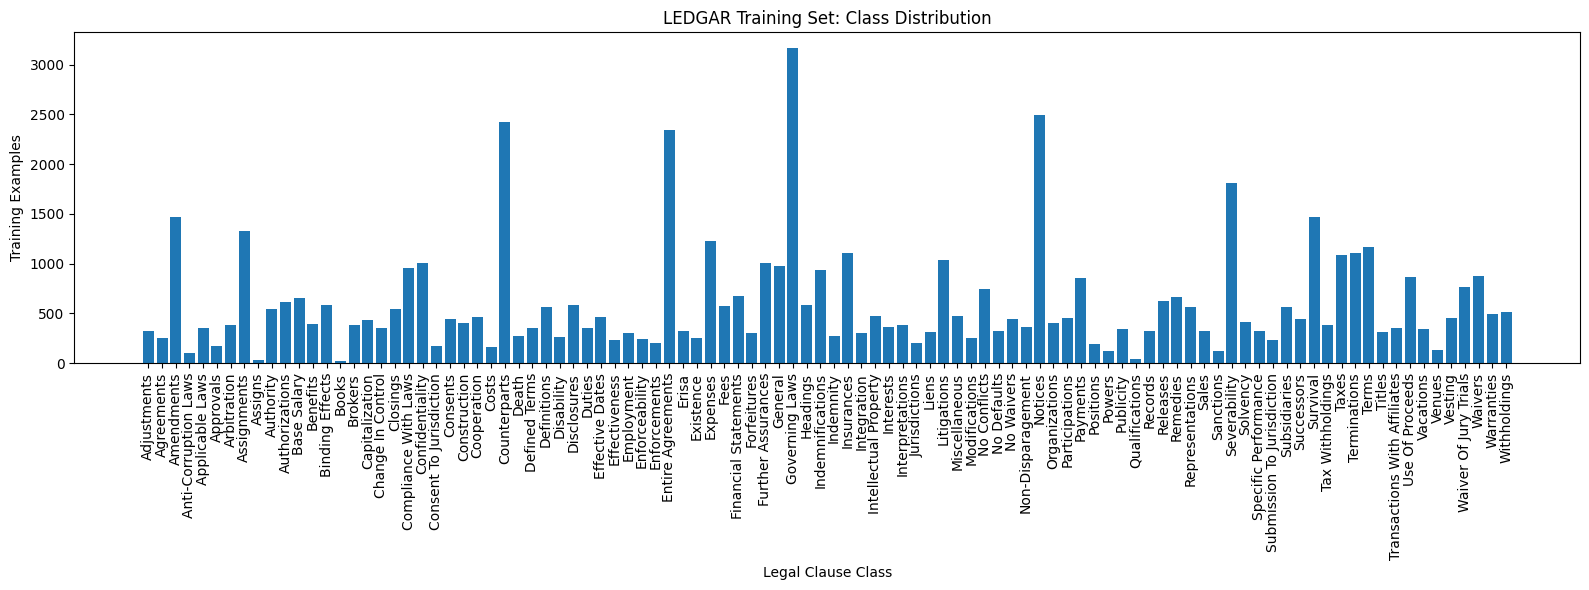

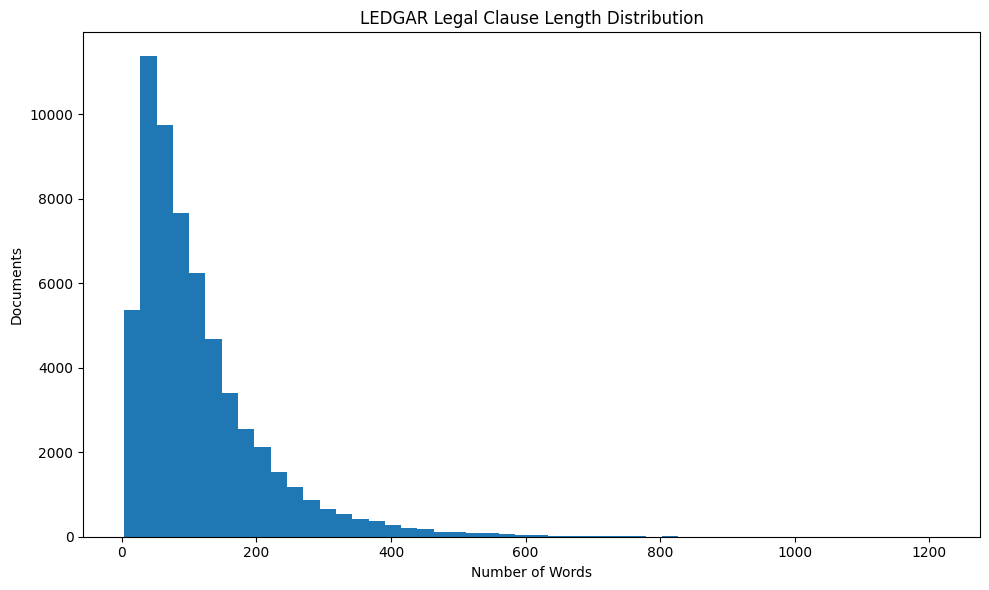

In [4]:
plt.figure(figsize=(16,6)); plt.bar(range(100),[label_counts[i] for i in range(100)]); plt.xlabel("Legal Clause Class"); plt.ylabel("Training Examples"); plt.title("LEDGAR Training Set: Class Distribution"); plt.xticks(range(100),label_names,rotation=90); plt.tight_layout(); plt.show()
plt.figure(figsize=(10,6)); plt.hist(lengths,bins=50); plt.xlabel("Number of Words"); plt.ylabel("Documents"); plt.title("LEDGAR Legal Clause Length Distribution"); plt.tight_layout(); plt.show()

## 3. Shared Text Splits and TF-IDF
TF-IDF is fitted only on training text to avoid validation/test leakage.

In [5]:
X_train=train["text"]; y_train=train["label"]
X_validation=validation["text"]; y_validation=validation["label"]
X_test=test["text"]; y_test=test["label"]

tfidf=TfidfVectorizer(lowercase=True,stop_words="english",ngram_range=(1,2),min_df=2,max_df=.95,sublinear_tf=True)
X_train_tfidf=tfidf.fit_transform(X_train); X_validation_tfidf=tfidf.transform(X_validation); X_test_tfidf=tfidf.transform(X_test)
print("Train TF-IDF:",X_train_tfidf.shape,"Validation:",X_validation_tfidf.shape,"Test:",X_test_tfidf.shape)
print("Vocabulary:",len(tfidf.vocabulary_))

Train TF-IDF: (60000, 210328) Validation: (10000, 210328) Test: (10000, 210328)
Vocabulary: 210328


## 4. Logistic Regression Baseline
The original notebook had a dimension mismatch because the final 10,000-feature model was evaluated with the original 210,328-feature validation matrix. This notebook fixes that ordering issue by using the same `tfidf_fast` transformer for both training and validation.

In [6]:
LOG_MODEL="logistic_regression_model.joblib"; LOG_VEC="tfidf_vectorizer.joblib"
tfidf_fast=TfidfVectorizer(lowercase=True,stop_words="english",ngram_range=(1,2),min_df=3,max_df=.95,max_features=10000,sublinear_tf=True)
X_train_fast=tfidf_fast.fit_transform(X_train); X_val_fast=tfidf_fast.transform(X_validation)
if os.path.exists(LOG_MODEL) and os.path.exists(LOG_VEC):
    model=joblib.load(LOG_MODEL); tfidf_fast=joblib.load(LOG_VEC); X_val_fast=tfidf_fast.transform(X_validation)
    print("Loaded saved Logistic Regression artifacts.")
else:
    model=LogisticRegression(max_iter=300,class_weight="balanced",solver="saga",random_state=SEED,n_jobs=-1)
    st=time.time(); model.fit(X_train_fast,y_train); print("Training time:",round(time.time()-st,2),"sec")
    joblib.dump(model,LOG_MODEL); joblib.dump(tfidf_fast,LOG_VEC)
y_pred=model.predict(X_val_fast)
accuracy=accuracy_score(y_validation,y_pred); macro_f1=f1_score(y_validation,y_pred,average="macro",zero_division=0); weighted_f1=f1_score(y_validation,y_pred,average="weighted",zero_division=0)
print("Accuracy:",round(accuracy,4),"Macro F1:",round(macro_f1,4),"Weighted F1:",round(weighted_f1,4))

Training time: 302.15 sec
Accuracy: 0.8211 Macro F1: 0.7538 Weighted F1: 0.8277


## 5. Random Forest
This is the strongest recorded classical model and becomes the production-style classifier.

In [ ]:
RF300="legal_clause_random_forest_300.joblib"
if os.path.exists(RF300): rf300=joblib.load(RF300)
else:
    rf300=RandomForestClassifier(n_estimators=100,class_weight="balanced",random_state=SEED,n_jobs=2); st=time.time(); 
    rf300.fit(X_train_tfidf,y_train); 
    print("Training time:",round(time.time()-st,2),"sec"); 
    joblib.dump(rf300,RF300)
    
y_pred_rf300=rf300.predict(X_validation_tfidf)
accuracy_rf=accuracy_score(y_validation,y_pred_rf300)
macro_f1_rf=f1_score(y_validation,y_pred_rf300,average="macro",zero_division=0) 
weighted_f1_rf=f1_score(y_validation,y_pred_rf300,average="weighted",zero_division=0)

print("Accuracy:",round(accuracy_rf,4),"Macro F1:",round(macro_f1_rf,4),"Weighted F1:",round(weighted_f1_rf,4))

Training time: 348.76 sec
Accuracy: 0.8615 Macro F1: 0.7874 Weighted F1: 0.8537


In [ ]:
rf_report=pd.DataFrame(classification_report(y_validation,y_pred_rf300,target_names=label_names,output_dict=True,zero_division=0)).transpose()
print("Weakest Random Forest classes:"); display(rf_report.sort_values("f1-score").head(10))
print("Strongest Random Forest classes:"); display(rf_report.sort_values("f1-score",ascending=False).head(10))

Weakest Random Forest classes:


,precision,recall,f1-score,support
Assigns,0.000000,0.000000,0.000000,3.0
Books,0.000000,0.000000,0.000000,0.0
Applicable Laws,0.800000,0.115942,0.202532,69.0
Qualifications,1.000000,0.250000,0.400000,8.0
Powers,1.000000,0.266667,0.421053,15.0
Venues,0.666667,0.315789,0.428571,19.0
Miscellaneous,0.916667,0.328358,0.483516,67.0
Enforcements,1.000000,0.369565,0.539683,46.0
Jurisdictions,0.866667,0.393939,0.541667,33.0
Costs,0.900000,0.409091,0.562500,22.0


Strongest Random Forest classes:


,precision,recall,f1-score,support
Base Salary,0.991304,1.000000,0.995633,114.0
Transactions With Affiliates,1.000000,0.973684,0.986667,76.0
Counterparts,0.955257,0.995338,0.974886,429.0
Erisa,0.965517,0.982456,0.973913,57.0
Waiver Of Jury Trials,0.948052,1.000000,0.973333,146.0
Non-Disparagement,0.981481,0.963636,0.972477,55.0
Brokers,0.970588,0.970588,0.970588,68.0
Participations,0.987179,0.950617,0.968553,81.0
Closings,0.974359,0.950000,0.962025,80.0
Insurances,0.935185,0.990196,0.961905,204.0


: 

## 6. XGBoost
The original variable-order error (`y_train_xgb` undefined) is fixed here by defining the labels before training.

In [ ]:
from xgboost import XGBClassifier
xgb_vec=TfidfVectorizer(lowercase=True,stop_words="english",ngram_range=(1,2),min_df=5,max_features=3000,sublinear_tf=True)
X_train_xgb=xgb_vec.fit_transform(X_train); X_val_xgb=xgb_vec.transform(X_validation)
y_train_xgb=np.array(y_train); y_val_xgb=np.array(y_validation)
XGB_PATH="xgb_legal_classifier.joblib"
if os.path.exists(XGB_PATH): xgb_model=joblib.load(XGB_PATH)
else:
    xgb_model=XGBClassifier(n_estimators=50,max_depth=3,learning_rate=.1,subsample=.8,colsample_bytree=.8,objective="multi:softmax",num_class=len(label_names),eval_metric="mlogloss",tree_method="hist",random_state=SEED,n_jobs=-1)
    st=time.time(); xgb_model.fit(X_train_xgb,y_train_xgb); print("Training time:",round(time.time()-st,2),"sec"); joblib.dump(xgb_model,XGB_PATH)
y_pred_xgb=xgb_model.predict(X_val_xgb)
accuracy_xgb=accuracy_score(y_val_xgb,y_pred_xgb); macro_f1_xgb=f1_score(y_val_xgb,y_pred_xgb,average="macro"); weighted_f1_xgb=f1_score(y_val_xgb,y_pred_xgb,average="weighted")
print("Accuracy:",round(accuracy_xgb,4),"Macro F1:",round(macro_f1_xgb,4),"Weighted F1:",round(weighted_f1_xgb,4))

## 7. PyTorch Neural Network
The original architecture uses 1,000 TF-IDF features, hidden layers of 512 and 256 units, dropout, class-weighted loss, and five epochs.

In [ ]:
torch_vec=TfidfVectorizer(lowercase=True,stop_words="english",ngram_range=(1,2),min_df=5,max_features=1000,sublinear_tf=True)
Xtr=torch_vec.fit_transform(X_train); Xv=torch_vec.transform(X_validation)
Xtr_t=torch.tensor(Xtr.toarray(),dtype=torch.float32); Xv_t=torch.tensor(Xv.toarray(),dtype=torch.float32)
ytr_t=torch.tensor(np.array(y_train),dtype=torch.long); yv_t=torch.tensor(np.array(y_validation),dtype=torch.long)
train_loader=DataLoader(TensorDataset(Xtr_t,ytr_t),batch_size=128,shuffle=True); val_loader=DataLoader(TensorDataset(Xv_t,yv_t),batch_size=256,shuffle=False)
class LegalDocumentNN(nn.Module):
    def __init__(self,input_size,num_classes):
        super().__init__(); self.network=nn.Sequential(nn.Linear(input_size,512),nn.ReLU(),nn.Dropout(.3),nn.Linear(512,256),nn.ReLU(),nn.Dropout(.3),nn.Linear(256,num_classes))
    def forward(self,x): return self.network(x)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
pytorch_model=LegalDocumentNN(1000,len(label_names)).to(device)
counts=np.bincount(np.array(y_train),minlength=len(label_names)); weights=len(y_train)/(len(label_names)*counts); weights[counts==0]=0
criterion=nn.CrossEntropyLoss(weight=torch.tensor(weights,dtype=torch.float32).to(device)); optimizer=torch.optim.Adam(pytorch_model.parameters(),lr=.001)
PYT="pytorch_legal_classifier.pt"
if os.path.exists(PYT): pytorch_model.load_state_dict(torch.load(PYT,map_location=device)); print("Loaded saved PyTorch model.")
else:
    for epoch in range(5):
        pytorch_model.train(); total=0; st=time.time()
        for Xb,yb in train_loader:
            Xb=Xb.to(device); yb=yb.to(device); optimizer.zero_grad(); out=pytorch_model(Xb); loss=criterion(out,yb); loss.backward(); optimizer.step(); total+=loss.item()
        print(f"Epoch {epoch+1}/5 | Average Loss: {total/len(train_loader):.4f} | Time: {time.time()-st:.1f}s")
    torch.save(pytorch_model.state_dict(),PYT)
pytorch_model.eval(); preds=[]; labs=[]
with torch.no_grad():
    for Xb,yb in val_loader:
        out=pytorch_model(Xb.to(device)); preds.extend(torch.argmax(out,1).cpu().numpy()); labs.extend(yb.numpy())
y_pred_pytorch=np.array(preds); y_val_pytorch=np.array(labs)
accuracy_pytorch=accuracy_score(y_val_pytorch,y_pred_pytorch); macro_f1_pytorch=f1_score(y_val_pytorch,y_pred_pytorch,average="macro"); weighted_f1_pytorch=f1_score(y_val_pytorch,y_pred_pytorch,average="weighted")
print("Accuracy:",round(accuracy_pytorch,4),"Macro F1:",round(macro_f1_pytorch,4),"Weighted F1:",round(weighted_f1_pytorch,4))

## 8. BERT, RoBERTa, and T5
These experiments use the same subsets and settings from the original project. Saved transformer directories are loaded on later Run All executions. If no saved directory exists, the models are trained.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, T5ForConditionalGeneration
bert_train=train.select(range(10000)); bert_validation=validation.select(range(2000))
def metrics(eval_pred):
    logits,labels=eval_pred; p=np.argmax(logits,axis=-1); return {"accuracy":accuracy_score(labels,p),"macro_f1":f1_score(labels,p,average="macro",zero_division=0),"weighted_f1":f1_score(labels,p,average="weighted",zero_division=0)}

# BERT
BERT_DIR="bert_legal_classifier"
if os.path.exists(os.path.join(BERT_DIR,"config.json")):
    bert_tok=AutoTokenizer.from_pretrained(BERT_DIR); bert_model=AutoModelForSequenceClassification.from_pretrained(BERT_DIR); print("Loaded saved BERT.")
else:
    bert_tok=AutoTokenizer.from_pretrained("bert-base-uncased")
    def bt(ex): return bert_tok(ex["text"],truncation=True,padding="max_length",max_length=256)
    bt_train=bert_train.map(bt,batched=True); bt_val=bert_validation.map(bt,batched=True); bt_train=bt_train.rename_column("label","labels"); bt_val=bt_val.rename_column("label","labels"); bt_train.set_format("torch"); bt_val.set_format("torch")
    bert_model=AutoModelForSequenceClassification.from_pretrained("bert-base-uncased",num_labels=len(label_names))
    args=TrainingArguments(output_dir=BERT_DIR,num_train_epochs=1,per_device_train_batch_size=8,per_device_eval_batch_size=8,learning_rate=2e-5,weight_decay=.01,logging_steps=100,eval_strategy="steps",eval_steps=500,save_strategy="no",report_to="none")
    tr=Trainer(model=bert_model,args=args,train_dataset=bt_train,eval_dataset=bt_val,compute_metrics=metrics); st=time.time(); tr.train(); print("BERT training minutes:",round((time.time()-st)/60,2)); bert_model.save_pretrained(BERT_DIR); bert_tok.save_pretrained(BERT_DIR)

# RoBERTa
ROB_DIR="roberta_legal_classifier"
if os.path.exists(os.path.join(ROB_DIR,"config.json")):
    rob_tok=AutoTokenizer.from_pretrained(ROB_DIR); rob_model=AutoModelForSequenceClassification.from_pretrained(ROB_DIR); print("Loaded saved RoBERTa.")
else:
    rob_tok=AutoTokenizer.from_pretrained("roberta-base")
    def rt(ex): return rob_tok(ex["text"],truncation=True,padding="max_length",max_length=256)
    rt_train=bert_train.map(rt,batched=True); rt_val=bert_validation.map(rt,batched=True); rt_train=rt_train.rename_column("label","labels"); rt_val=rt_val.rename_column("label","labels"); rt_train.set_format("torch"); rt_val.set_format("torch")
    rob_model=AutoModelForSequenceClassification.from_pretrained("roberta-base",num_labels=len(label_names))
    args=TrainingArguments(output_dir=ROB_DIR,num_train_epochs=1,per_device_train_batch_size=8,per_device_eval_batch_size=8,learning_rate=2e-5,weight_decay=.01,logging_steps=100,eval_strategy="steps",eval_steps=500,save_strategy="no",report_to="none")
    tr=Trainer(model=rob_model,args=args,train_dataset=rt_train,eval_dataset=rt_val,compute_metrics=metrics); st=time.time(); tr.train(); print("RoBERTa training minutes:",round((time.time()-st)/60,2)); rob_model.save_pretrained(ROB_DIR); rob_tok.save_pretrained(ROB_DIR)

# T5
T5_DIR="t5_legal_classifier"
if os.path.exists(os.path.join(T5_DIR,"config.json")):
    t5_tok=AutoTokenizer.from_pretrained(T5_DIR); t5_model=T5ForConditionalGeneration.from_pretrained(T5_DIR); print("Loaded saved T5.")
else:
    t5_tok=AutoTokenizer.from_pretrained("t5-small")
    def prep(ex):
        inputs=["classify legal clause: "+t for t in ex["text"]]; targets=[label_names[i] for i in ex["label"]]
        mi=t5_tok(inputs,max_length=256,truncation=True,padding="max_length"); lab=t5_tok(targets,max_length=32,truncation=True,padding="max_length"); mi["labels"]=lab["input_ids"]; return mi
    t5_train=bert_train.map(prep,batched=True); t5_val=bert_validation.map(prep,batched=True); t5_model=T5ForConditionalGeneration.from_pretrained("t5-small")
    args=TrainingArguments(output_dir=T5_DIR,num_train_epochs=1,per_device_train_batch_size=8,per_device_eval_batch_size=8,learning_rate=3e-4,weight_decay=.01,logging_steps=100,eval_strategy="steps",eval_steps=500,save_strategy="no",report_to="none")
    tr=Trainer(model=t5_model,args=args,train_dataset=t5_train,eval_dataset=t5_val); st=time.time(); tr.train(); print("T5 training minutes:",round((time.time()-st)/60,2)); t5_model.save_pretrained(T5_DIR); t5_tok.save_pretrained(T5_DIR)

### Transformer evaluation
The original BERT/RoBERTa results came from Trainer evaluation during training. T5 prediction required a memory-safe generation loop because `Trainer.predict()` caused an MPS out-of-memory error.

In [ ]:
# Recreate T5 validation data if it was not created in the training branch.
def prep(ex):
    inputs=["classify legal clause: "+t for t in ex["text"]]; targets=[label_names[i] for i in ex["label"]]
    mi=t5_tok(inputs,max_length=256,truncation=True,padding="max_length"); lab=t5_tok(targets,max_length=32,truncation=True,padding="max_length"); mi["labels"]=lab["input_ids"]; return mi
if "t5_val" not in globals(): t5_val=bert_validation.map(prep,batched=True)

gc.collect()
if torch.backends.mps.is_available(): torch.mps.empty_cache()
t5_device=torch.device("mps" if torch.backends.mps.is_available() else "cpu"); t5_model.to(t5_device); t5_model.eval()
preds=[]; actual=[]
for start in range(0,len(t5_val),8):
    b=t5_val[start:start+8]; ids=torch.tensor(b["input_ids"]).to(t5_device); mask=torch.tensor(b["attention_mask"]).to(t5_device)
    with torch.no_grad(): gen=t5_model.generate(input_ids=ids,attention_mask=mask,max_length=32)
    preds.extend(t5_tok.batch_decode(gen,skip_special_tokens=True)); actual.extend([label_names[int(i)] for i in b["label"]]); del ids,mask,gen
    if start%400==0 and torch.backends.mps.is_available(): torch.mps.empty_cache()
preds=[p.strip() for p in preds]
t5_accuracy=accuracy_score(actual,preds); t5_macro_f1=f1_score(actual,preds,labels=label_names,average="macro",zero_division=0); t5_weighted_f1=f1_score(actual,preds,labels=label_names,average="weighted",zero_division=0)
print("T5 Accuracy:",round(t5_accuracy,4),"Macro F1:",round(t5_macro_f1,4),"Weighted F1:",round(t5_weighted_f1,4))

## 9. Final Model Comparison
These are the recorded project results.

In [ ]:
results=pd.DataFrame({"Model":["TF-IDF + Logistic Regression","TF-IDF + Random Forest","TF-IDF + XGBoost","PyTorch Neural Network","BERT","RoBERTa","T5"],"Accuracy":[.8328,.8615,.8120,.7903,.6425,.7045,.7610],"Macro F1":[.7710,.7874,.7279,.7125,.3609,.4607,.6243],"Weighted F1":[.8379,.8537,.8039,.7952,.5483,.6368,.7446]})
display(results)
ax=results.plot(x="Model",y=["Accuracy","Macro F1","Weighted F1"],kind="bar",figsize=(11,6)); ax.set_ylabel("Score"); ax.set_ylim(0,1); ax.set_title("Validation Performance Across Models"); plt.xticks(rotation=30,ha="right"); plt.tight_layout(); plt.show()

## 10. Random Forest Error Analysis
Inspect the most frequent class confusions and the full confusion matrix.

In [ ]:
RF_PROD="legal_clause_random_forest.joblib"
if os.path.exists(RF_PROD): rf_model=joblib.load(RF_PROD)
else:
    rf_model=RandomForestClassifier(n_estimators=200,max_depth=None,class_weight="balanced",random_state=SEED,n_jobs=-1); rf_model.fit(X_train_tfidf,y_train); joblib.dump(rf_model,RF_PROD)
y_pred_rf=rf_model.predict(X_validation_tfidf)
pairs=Counter((a,p) for a,p in zip(y_validation,y_pred_rf) if a!=p)
rows=[{"Actual":label_names[a],"Predicted":label_names[p],"Count":n} for (a,p),n in pairs.most_common(20)]
display(pd.DataFrame(rows))
cm=confusion_matrix(y_validation,y_pred_rf); plt.figure(figsize=(18,16)); sns.heatmap(cm,cmap="Blues",xticklabels=label_names,yticklabels=label_names); plt.title("Random Forest Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.xticks(rotation=90); plt.yticks(rotation=0); plt.tight_layout(); plt.show()

## 11. Explainability
Global feature importance shows which TF-IDF terms are influential across the Random Forest. Local explanation shows which features contribute most to one prediction.

In [ ]:
RF_EX="legal_clause_random_forest_explain.joblib"
if os.path.exists(RF_EX): rf_explain=joblib.load(RF_EX)
else:
    rf_explain=RandomForestClassifier(n_estimators=100,max_depth=None,class_weight="balanced",random_state=SEED,n_jobs=-1); st=time.time(); rf_explain.fit(X_train_tfidf,y_train); print("Training time:",round(time.time()-st,2),"sec"); joblib.dump(rf_explain,RF_EX)
features=tfidf.get_feature_names_out(); imp=pd.DataFrame({"feature":features,"importance":rf_explain.feature_importances_}).sort_values("importance",ascending=False)
display(imp.head(30))
top=imp.head(15).sort_values("importance"); plt.figure(figsize=(10,7)); plt.barh(top.feature,top.importance); plt.xlabel("Importance"); plt.title("Top 15 Random Forest Features"); plt.tight_layout(); plt.show()

In [ ]:
def predict_legal_clause(text):
    x=tfidf.transform([text]); pred=rf_model.predict(x)[0]; probs=rf_model.predict_proba(x)[0]; return label_names[pred],probs[pred]

def predict_top3_legal_clauses(text):
    x=tfidf.transform([text]); probs=rf_model.predict_proba(x)[0]; idx=probs.argsort()[-3:][::-1]; return pd.DataFrame({"Clause":[label_names[i] for i in idx],"Probability":[round(float(probs[i]),4) for i in idx]})

def explain_prediction(text,top_n=10):
    x=tfidf.transform([text]); pred=rf_model.predict(x)[0]; vals=x.toarray()[0]; ex=pd.DataFrame({"Feature":features,"TF-IDF":vals,"Importance":rf_model.feature_importances_}); ex["Contribution"]=ex["TF-IDF"]*ex["Importance"]; return label_names[pred],ex[ex.Contribution>0].sort_values("Contribution",ascending=False).head(top_n)

sample_text="The substantive laws of the State of Texas will govern the validity, construction and enforcement of this Agreement."
pred,conf=predict_legal_clause(sample_text); print("Predicted Clause:",pred); print("Confidence:",round(conf,4)); display(predict_top3_legal_clauses(sample_text)); pred,ex=explain_prediction(sample_text); display(ex)

## 12. Conclusion
The project demonstrates an end-to-end 100-class legal clause classification workflow. The recorded experiments show the TF-IDF + Random Forest approach achieving 86.15% validation accuracy and 78.74% Macro F1, while the explainability workflow turns the trained model into a reusable classifier that can return a predicted category, confidence, top alternatives, and influential TF-IDF features.

In [ ]:
for path in ["legal_clause_random_forest.joblib","legal_clause_tfidf.joblib","logistic_regression_model.joblib","tfidf_vectorizer.joblib","xgb_legal_classifier.joblib","pytorch_legal_classifier.pt"]:
    print(path, os.path.exists(path))
for d in ["bert_legal_classifier","roberta_legal_classifier","t5_legal_classifier"]:
    print(d, os.path.isdir(d))